In [1]:
from typing import Any, cast

from datasets import Dataset
from datasets import load_dataset as hf_load
from maite_datasets.adapters import from_huggingface

# Download MNIST training split (60 000 images of 28x28 handwritten digits)
mnist_train = cast(Dataset, hf_load("ylecun/mnist", split="train"))

# Reference: first 2 000 images, wrapped as a MAITE dataset
ref_maite = from_huggingface(mnist_train.select(range(2000)))

print(f"Reference: {len(ref_maite)} images")
print(f"Sample shape: image={ref_maite[0][0].shape}, dtype={ref_maite[0][0].dtype}, label={ref_maite[0][1]}")

/home/aweng/2033/dataeval-flow/.nox/docs/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Reference: 2000 images
Sample shape: image=(1, 28, 28), dtype=uint8, label=[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


In [2]:
from collections.abc import Mapping

import numpy as np
from numpy.typing import NDArray


class InvertedTailDataset:
    """Wraps a MAITE dataset and color-inverts images by class label.

    Parameters
    ----------
    dataset
        A MAITE-compatible dataset returning (image, target, metadata) tuples.
    classes_to_invert
        Class labels to color-invert.
    """

    def __init__(self, dataset: Any, classes_to_invert: list[int] | None = None) -> None:
        self._dataset = dataset
        self._classes_to_invert = classes_to_invert or []
        self.metadata = {"id": f"inverted_tail_{len(self._classes_to_invert)}", "original_metadata": dataset.metadata}

    def __len__(self) -> int:
        return len(self._dataset)

    def __getitem__(self, index: int) -> tuple[NDArray[Any], Any, Mapping[str, Any]]:
        image, target, metadata = self._dataset[index]
        if np.argmax(target) in self._classes_to_invert:
            image = 255 - np.asarray(image)
        return image, target, metadata


# Incoming: next 500 images (indices 2000–2500), odd-digit classes get inverted
incoming_hf = mnist_train.select(range(2000, 2500))
incoming_maite = from_huggingface(incoming_hf)
incoming_dataset = InvertedTailDataset(incoming_maite, classes_to_invert=[1, 3, 5, 7, 9])

n_inverted = sum(1 for i in range(len(incoming_dataset)) if np.argmax(incoming_dataset[i][1]) in [1, 3, 5, 7, 9])
print(f"Incoming: {len(incoming_dataset)} images")
print(f"  In-distribution (even digits): {len(incoming_dataset) - n_inverted}")
print(f"  Out-of-distribution (inverted odd digits): {n_inverted}")

Incoming: 500 images
  In-distribution (even digits): 262
  Out-of-distribution (inverted odd digits): 238


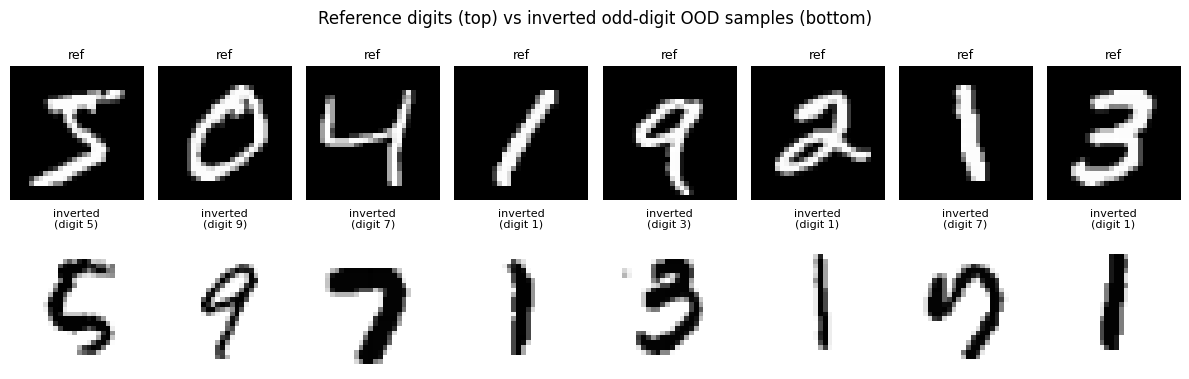

In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 8, figsize=(12, 4))

# Row 0: sample reference images
for col in range(8):
    img_arr = np.asarray(ref_maite[col][0]).squeeze()
    axes[0, col].imshow(img_arr, cmap="gray")
    axes[0, col].set_title("ref", fontsize=9)
    axes[0, col].axis("off")

# Row 1: color-inverted OOD samples (odd-digit classes)
ood_indices = [i for i in range(len(incoming_dataset)) if np.argmax(incoming_dataset[i][1]) in [1, 3, 5, 7, 9]]
for col in range(8):
    img_arr = np.asarray(incoming_dataset[ood_indices[col]][0]).squeeze()
    label = int(np.argmax(incoming_dataset[ood_indices[col]][1]))
    axes[1, col].imshow(img_arr, cmap="gray")
    axes[1, col].set_title(f"inverted\n(digit {label})", fontsize=8)
    axes[1, col].axis("off")

axes[0, 0].set_ylabel("Reference", fontsize=9)
axes[1, 0].set_ylabel("Inverted", fontsize=9)

fig.suptitle("Reference digits (top) vs inverted odd-digit OOD samples (bottom)", fontsize=12)
plt.tight_layout()
plt.show()

In [4]:
from dataeval_flow.config import DatasetProtocolConfig, FlattenExtractorConfig, PipelineConfig, SourceConfig

# --- Datasets (in-memory via DatasetProtocolConfig) ---
ref_config = DatasetProtocolConfig(
    name="reference",
    format="maite",
    dataset=ref_maite,
)

incoming_config = DatasetProtocolConfig(
    name="incoming",
    format="maite",
    dataset=incoming_dataset,
)

# --- Extractor ---
# Flatten reshapes each 28x28 grayscale image into a 784-D feature vector
extractor_config = FlattenExtractorConfig(name="flatten", batch_size=64)

In [5]:
from pathlib import Path

from dataeval_flow.config import OODDetectionTaskConfig, OODDetectionWorkflowConfig
from dataeval_flow.workflow import run_task
from dataeval_flow.workflows.ood.params import (
    OODDetectorDomainClassifier,
    OODDetectorKNeighbors,
    OODHealthThresholds,
)

task = OODDetectionTaskConfig(
    name="mnist-ood-check",
    workflow="mnist-ood",
    sources=["ref_src", "inc_src"],
    extractor="flatten",
)

config = PipelineConfig(
    datasets=[ref_config, incoming_config],
    sources=[
        SourceConfig(name="ref_src", dataset="reference"),
        SourceConfig(name="inc_src", dataset="incoming"),
    ],
    extractors=[extractor_config],
    workflows=[
        OODDetectionWorkflowConfig(
            name="mnist-ood",
            detectors=[
                OODDetectorKNeighbors(
                    k=10,
                    distance_metric="cosine",
                    threshold_perc=99.0,
                ),
                OODDetectorDomainClassifier(
                    n_folds=3,
                    n_repeats=3,
                    threshold_perc=99.0,
                ),
            ],
            health_thresholds=OODHealthThresholds(
                ood_pct_warning=5.0,  # warn if >5% of samples are OOD
                ood_pct_info=1.0,  # info if >1% of samples are OOD
            ),
            metadata_insights=True,
            max_ood_insights=50,
        ),
    ],
)

In [6]:
result = run_task(task, config, cache_dir=Path("./cache"))

/home/aweng/2033/dataeval-flow/.nox/docs/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,


In [7]:
print(result.report())


  OOD DETECTION COMPLETE. REFERENCE: 2000 ITEMS, TEST: 500 ITEMS.
  Timestamp:    2026-06-09T17:46:11.451449+00:00
  Duration:     7.28s
  Source:       ref_src (reference)
                inc_src (incoming)
  Model:        flatten (flatten)
--------------------------------------------------------------------------------

  SUMMARY
  -------
  K-Neighbors (threshold_perc=99.0) ...................................   [!!]
  Domain Classifier (n_folds=3, n_repeats=3, threshold_perc=99.0) .....   [!!]
  Aggregate OOD (all detectors agree) .................................   [!!]
  Unique OOD Samples (single-detector only) ...........................   [..]
  OOD Factor Predictors ...............................................   [..]
  OOD Sample Metadata Deviations ......................................   [..]

  Health: 3 warning(s) [!!] — review flagged findings

  K-NEIGHBORS (THRESHOLD_PERC=99.0)
  K-Neighbors (threshold_perc=99.0): 239/500 samples OOD (47.8%)

  
        Range    In 

In [8]:
raw = result.data.raw

print(f"Reference size:  {raw.reference_size}")
print(f"Test size:       {raw.test_size}")
print(f"OOD samples:     {len(raw.ood_indices)} (union across all detectors)")
print()

for method, det_result in raw.detectors.items():
    print(f"-- {method} --")
    print(f"  OOD count:     {det_result['ood_count']} / {det_result['total_count']}")
    print(f"  OOD percentage: {det_result['ood_percentage']:.1f}%")
    print(f"  Threshold:     {det_result['threshold_score']:.4f}")
    print()

Reference size:  2000
Test size:       500
OOD samples:     245 (union across all detectors)

-- kneighbors --
  OOD count:     239 / 500
  OOD percentage: 47.8%
  Threshold:     0.3889

-- domain_classifier --
  OOD count:     244 / 500
  OOD percentage: 48.8%
  Threshold:     0.5027



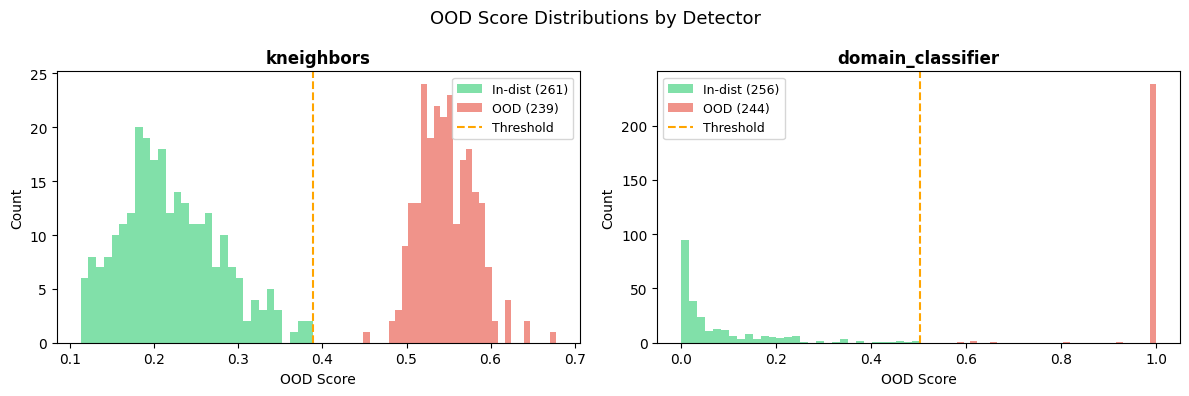

In [9]:
fig, axes = plt.subplots(1, len(raw.detectors), figsize=(6 * len(raw.detectors), 4))
if len(raw.detectors) == 1:
    axes = [axes]

ood_set = set(raw.ood_indices)

for ax, (method, det_result) in zip(axes, raw.detectors.items(), strict=True):
    samples = det_result.get("samples", [])
    if not samples:
        continue

    in_scores = [s["score"] for s in samples if not s["is_ood"]]
    ood_scores = [s["score"] for s in samples if s["is_ood"]]

    ax.hist(in_scores, bins=30, alpha=0.6, label=f"In-dist ({len(in_scores)})", color="#2ecc71")
    ax.hist(ood_scores, bins=30, alpha=0.6, label=f"OOD ({len(ood_scores)})", color="#e74c3c")
    ax.axvline(x=det_result["threshold_score"], color="orange", linestyle="--", label="Threshold")
    ax.set_xlabel("OOD Score")
    ax.set_ylabel("Count")
    ax.set_title(method, fontsize=12, fontweight="bold")
    ax.legend(fontsize=9)

fig.suptitle("OOD Score Distributions by Detector", fontsize=13)
plt.tight_layout()
plt.show()

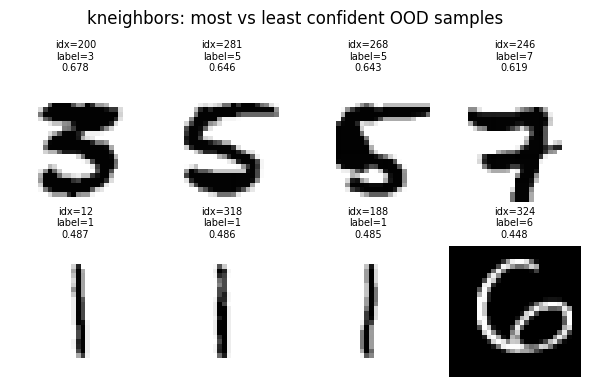

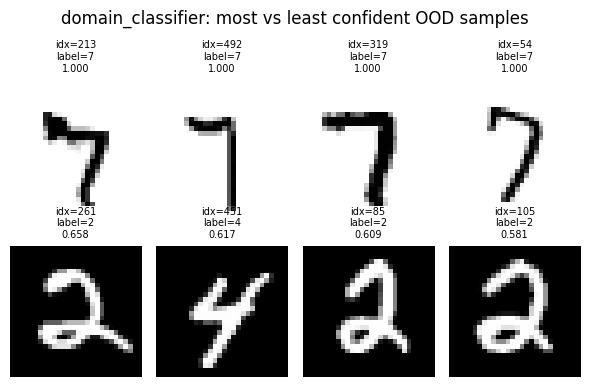

In [10]:
cols = 4

for method, det_result in raw.detectors.items():
    samples = det_result.get("samples", [])
    ood_samples = sorted(
        [(s["index"], s["score"]) for s in samples if s["is_ood"]],
        key=lambda x: -x[1],
    )
    if not ood_samples:
        continue

    top = ood_samples[:cols]
    bottom = ood_samples[-cols:]

    fig, axes = plt.subplots(2, cols, figsize=(1.5 * cols, 4))

    for row_idx, (row_label, row_items) in enumerate([("Top 4 (most OOD)", top), ("Bottom 4 (least OOD)", bottom)]):
        for col, (idx, score) in enumerate(row_items):
            img_data, target, _ = incoming_dataset[idx]
            img_arr = np.asarray(img_data)
            if img_arr.ndim == 3 and img_arr.shape[0] in (1, 3):
                img_arr = img_arr.squeeze(0) if img_arr.shape[0] == 1 else np.moveaxis(img_arr, 0, -1)
            axes[row_idx, col].imshow(img_arr, cmap="gray")
            label = int(np.argmax(target)) if np.asarray(target).ndim > 0 else int(target)
            axes[row_idx, col].set_title(f"idx={idx}\nlabel={label}\n{score:.3f}", fontsize=7)
            axes[row_idx, col].axis("off")
        for col in range(len(row_items), cols):
            axes[row_idx, col].axis("off")
        axes[row_idx, 0].set_ylabel(row_label, fontsize=8)

    fig.suptitle(f"{method}: most vs least confident OOD samples", fontsize=12)
    plt.tight_layout()
    plt.show()

In [11]:
if raw.factor_predictors:
    print("Factor Predictors (mutual information with OOD status):")
    print("-" * 50)
    for factor, mi in raw.factor_predictors.items():
        bar = "#" * int(mi * 20)
        print(f"  {factor:20s}  {mi:.4f} bits  {bar}")
    print()

if raw.factor_deviations:
    print(f"Factor Deviations (top {min(10, len(raw.factor_deviations))} OOD samples):")
    print("-" * 50)
    for dev in raw.factor_deviations[:10]:
        top_factors = list(dev["deviations"].items())[:3]
        factors_str = ", ".join(f"{k}={v:.2f}" for k, v in top_factors)
        print(f"  Sample {dev['index']:4d}: {factors_str}")

Factor Predictors (mutual information with OOD status):
--------------------------------------------------
  class_label           0.9182 bits  ##################
  f_zeros               0.9141 bits  ##################
  f_brightness          0.9103 bits  ##################
  f_contrast            0.9090 bits  ##################
  f_mean                0.9076 bits  ##################
  f_skew                0.9051 bits  ##################
  f_darkness            0.8894 bits  #################
  f_kurtosis            0.1421 bits  ##
  f_entropy             0.1256 bits  ##
  f_std                 0.0880 bits  #
  f_var                 0.0869 bits  #
  f_sharpness           0.0648 bits  #

Factor Deviations (top 10 OOD samples):
--------------------------------------------------
  Sample    0: f_mean=24.56, f_zeros=22.57, f_skew=12.37
  Sample    6: f_mean=26.21, f_zeros=22.68, f_skew=14.49
  Sample    7: f_mean=22.72, f_zeros=22.68, f_skew=10.80
  Sample    8: f_mean=26.28, f_zeros=22.64

In [12]:
json_str = result.export(fmt="json")
print(f"JSON output: {len(json_str)} characters")
print(json_str[:600] + "\n...")

JSON output: 160016 characters
{
  "metadata": {
    "version": "1.0",
    "timestamp": "2026-06-09T17:46:11.451449Z",
    "dataset_id": "reference,incoming",
    "label_source": "protocol",
    "model_id": "flatten (flatten)",
    "preprocessor_id": null,
    "selection_id": null,
    "source_descriptions": [
      "ref_src (reference)",
      "inc_src (incoming)"
    ],
    "resolved_config": {
      "sources": [
        {
          "name": "ref_src",
          "dataset": "reference",
          "dataset_config": {
            "name": "reference",
            "format": "maite",
            "version": "1",
            "data
...
